# What Causes Americans to Spend Millions of Hours Waiting in Airports?
# A Data Story on Flight Delays and Cancellations in the United States

1. Executive Summary

## Executive Summary

Every year, millions of travelers spend countless hours waiting in airports due to delayed and cancelled flights.

While weather is often blamed for flight disruptions, this analysis investigates whether other factors play a larger role.

Our hypothesis is:

> Operational factors such as airline scheduling, aircraft turnaround times, and airport congestion contribute more to delays than weather-related events.

By analyzing flight delay and cancellation data, we seek to answer:

1. How severe is the delay problem?
2. What causes most delays?
3. Which airlines and airports experience the most delays?
4. Are delays seasonal?
5. Is weather truly the primary cause of passenger waiting time?

2. Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

3. Load Data

In [6]:
df = pd.read_csv(r"C:\Users\kedha\Downloads\flights.csv")

C:\Users\kedha\AppData\Local\Temp\ipykernel_28872\4214358222.py:1: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\kedha\Downloads\flights.csv")


4. Initial Exploration

What does our dataset contain?

In [7]:
df.shape 

(5819079, 31)

In [8]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [10]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


The dataset contains information on:

- Flight schedules
- Departure delays
- Arrival delays
- Cancellation status
- Delay causes
- Origin and destination airports
- Airlines

Before investigating causes, we first need to understand the overall scale of the problem.

5. How Big Is The Delay Problem?

How many flights are delayed?

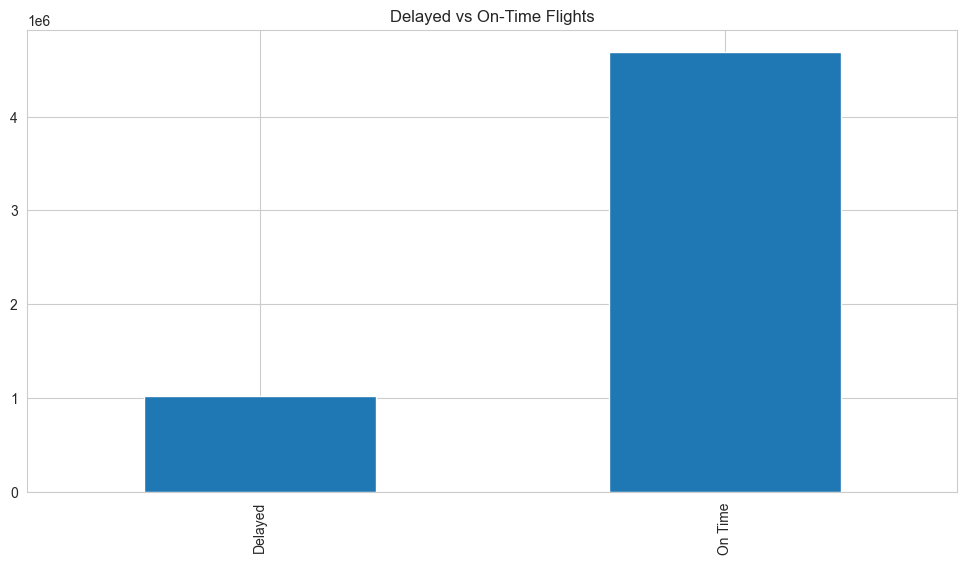

In [11]:
delayed = (df["ARRIVAL_DELAY"] > 15).sum()

on_time = (df["ARRIVAL_DELAY"] <= 15).sum()

counts = pd.Series({
    "Delayed": delayed,
    "On Time": on_time
})

counts.plot(kind="bar")
plt.title("Delayed vs On-Time Flights")
plt.show()

At first glance, the U.S. airline system appears highly reliable, with roughly 80% of flights arriving on time.

However, more than one million flights experienced delays during the year. Even relatively small delays can accumulate into millions of hours of passenger waiting time nationwide.

This raises an important question:

> What is causing these delays?

6. How Long Are Delays?

What does the distribution of delays look like?

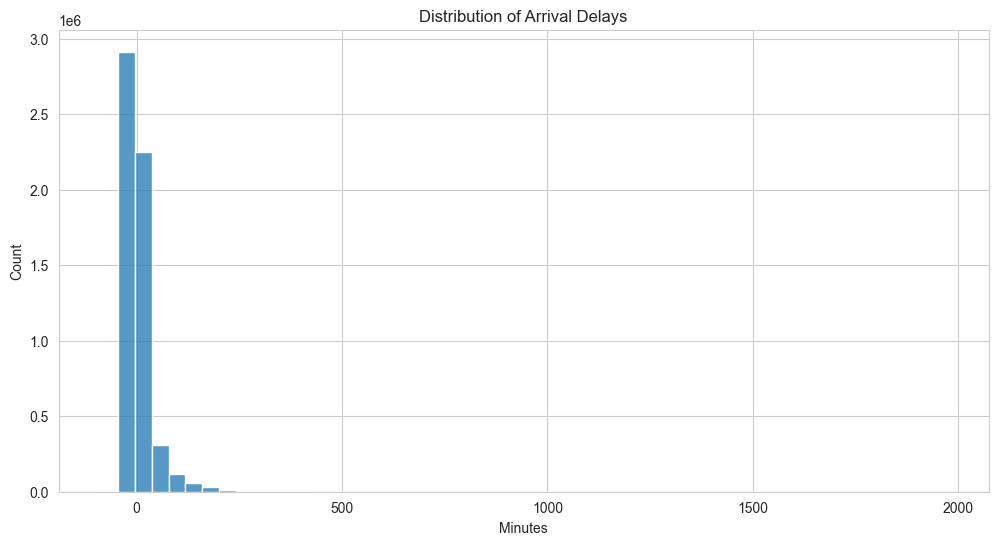

In [12]:
sns.histplot(
    df["ARRIVAL_DELAY"],
    bins=50
)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Minutes")
plt.show()

Most travelers experience little or no delay, but a small number of severely delayed flights account for a disproportionate amount of the millions of hours Americans spend waiting in airports. Understanding what causes these extreme delays is critical to reducing overall passenger waiting time.

If a relatively small number of flights are responsible for most delay time, what factors are causing these delays: weather, airline operations, airport congestion, or something else?

7. Delays or Cancellations?

Which problem affects more passengers?

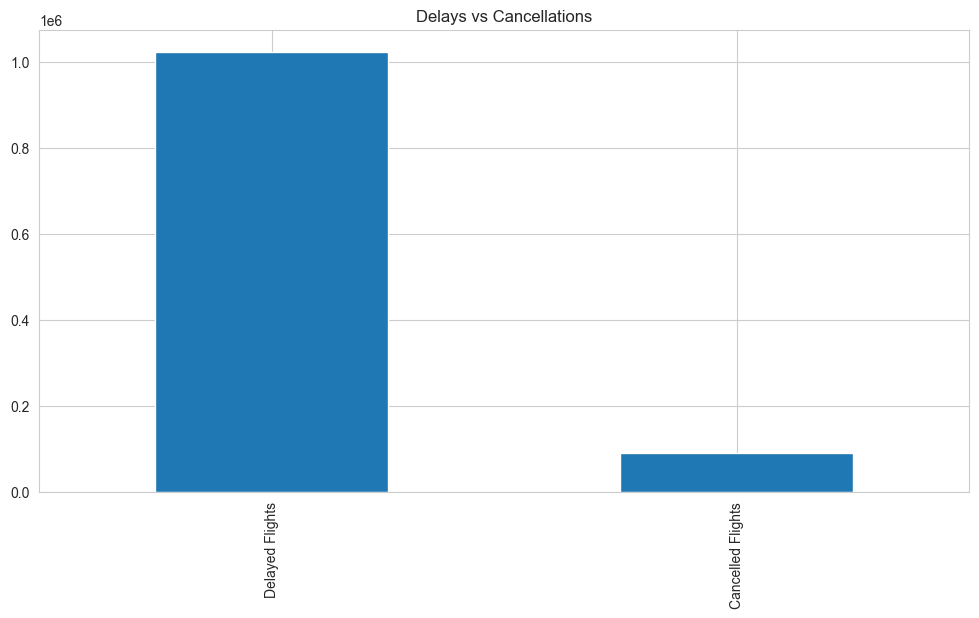

In [13]:
cancelled = df["CANCELLED"].sum()

delayed = (df["ARRIVAL_DELAY"] > 15).sum()

comparison = pd.Series({
    "Delayed Flights": delayed,
    "Cancelled Flights": cancelled
})

comparison.plot(kind="bar")
plt.title("Delays vs Cancellations")
plt.show()

The primary challenge facing air travelers is not cancelled flights but delayed flights. Since delays occur far more frequently, reducing delay rates has the greatest potential to improve passenger experience and decrease total waiting time across the U.S. air transportation system.

What are the primary causes of these delays, and which factors contribute the most to passenger waiting time?

8. What Causes Delays?

Which factors generate the most delay minutes?

In [14]:
delay_causes = pd.DataFrame({
    "Air System": df["AIR_SYSTEM_DELAY"].sum(),
    "Security": df["SECURITY_DELAY"].sum(),
    "Airline": df["AIRLINE_DELAY"].sum(),
    "Late Aircraft": df["LATE_AIRCRAFT_DELAY"].sum(),
    "Weather": df["WEATHER_DELAY"].sum()
}, index=[0]).T

delay_causes.columns = ["Minutes"]

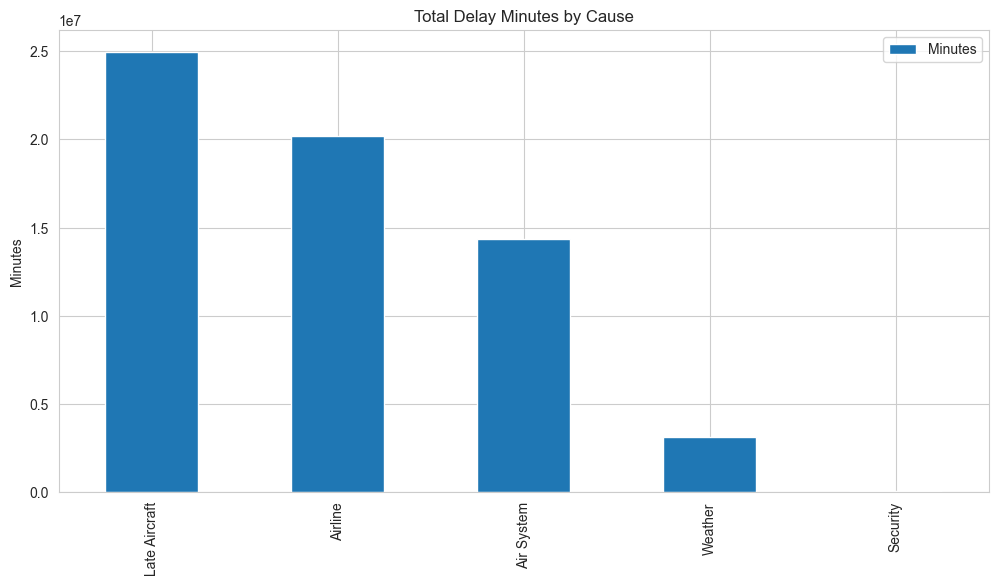

In [15]:
delay_causes.sort_values(
    "Minutes",
    ascending=False
).plot(
    kind="bar"
)

plt.title("Total Delay Minutes by Cause")
plt.ylabel("Minutes")
plt.show()

Weather is not the dominant source of delays.

Operational factors such as carrier delays, air traffic congestion, and late-arriving aircraft contribute significantly more total delay minutes.

9. Percentage Breakdown

How much does each cause contribute?

In [18]:

delay_causes = pd.DataFrame({
    "Cause": [
        "Airline",
        "Weather",
        "Air System",
        "Security",
        "Late Aircraft"
    ],
    "Minutes": [
        df["AIRLINE_DELAY"].sum(),
        df["WEATHER_DELAY"].sum(),
        df["AIR_SYSTEM_DELAY"].sum(),
        df["SECURITY_DELAY"].sum(),
        df["LATE_AIRCRAFT_DELAY"].sum()
    ]
})



delay_causes["Percent"] = (
    delay_causes["Minutes"] /
    delay_causes["Minutes"].sum()
) * 100



delay_causes = delay_causes.sort_values(
    "Percent",
    ascending=False
)



delay_causes

,Cause,Minutes,Percent
4,Late Aircraft,24961931.0,39.842278
0,Airline,20172956.0,32.198491
2,Air System,14335762.0,22.881620
1,Weather,3100233.0,4.948349
3,Security,80985.0,0.129262


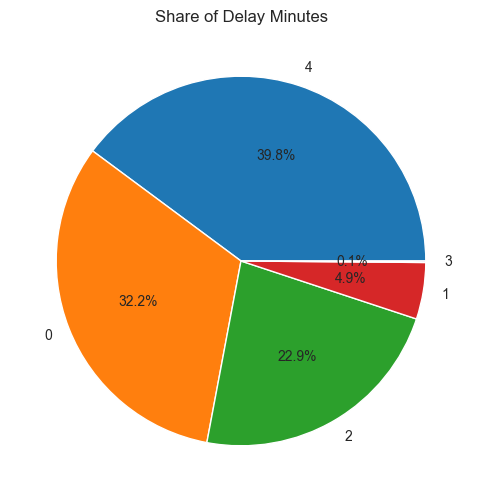

In [19]:
delay_causes["Percent"].plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Share of Delay Minutes")
plt.show()

Contrary to popular perception, weather is not the primary reason Americans spend millions of hours waiting in airports. More than 90% of delay time is driven by operational factors such as late-arriving aircraft, airline scheduling and maintenance issues, and air traffic system congestion.

Operational inefficiencies, not weather are the dominant cause of passenger waiting time in the U.S. air transportation system.

10. Which Airlines Have The Worst Delays?

Are some airlines more affected than others?

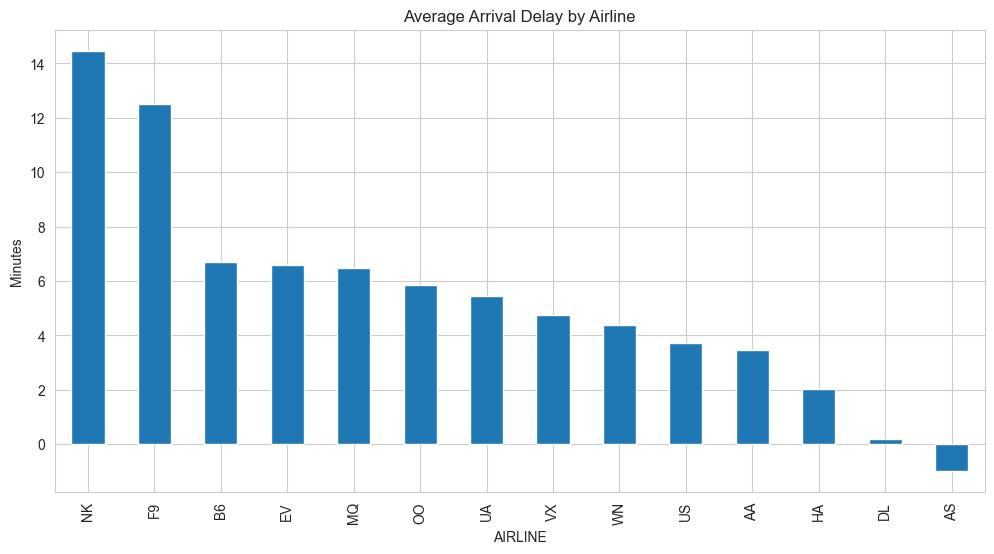

In [20]:
airline_delays = (
    df.groupby("AIRLINE")
      ["ARRIVAL_DELAY"]
      .mean()
      .sort_values(ascending=False)
)

airline_delays.plot(kind="bar")
plt.title("Average Arrival Delay by Airline")
plt.ylabel("Minutes")
plt.show()

The wide gap between the best and worst performing airlines suggests that delays are not solely the result of uncontrollable external factors. Operational decisions, scheduling practices, fleet management, and turnaround efficiency appear to have a significant impact on airline punctuality.

If weather were the primary driver of delays, we would expect airlines to experience similar average delays. Instead, the large differences between carriers indicate that operational performance is a major factor influencing passenger waiting time.

11. Which Airports Generate The Most Waiting Time?

Which airports contribute most to delays?

In [21]:
airport_delay = (
    df.groupby("ORIGIN_AIRPORT")
      ["ARRIVAL_DELAY"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

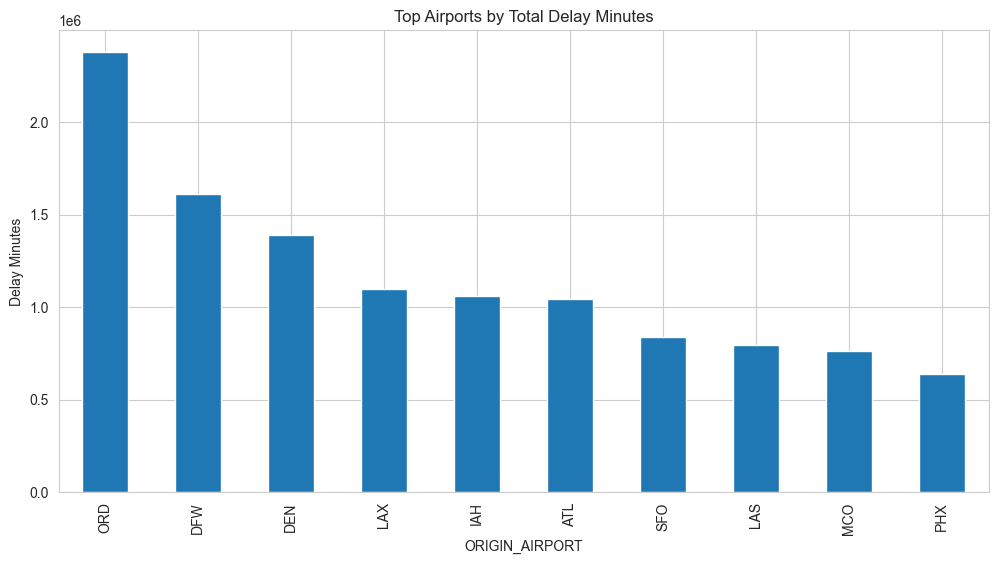

In [22]:
airport_delay.plot(kind="bar")
plt.title("Top Airports by Total Delay Minutes")
plt.ylabel("Delay Minutes")
plt.show()

Large hub airports account for a disproportionate share of total delay minutes.

Congestion at these airports can ripple throughout the national flight network.

12. Seasonal Patterns

Do delays vary throughout the year?

In [23]:
monthly_delays = (
    df.groupby("MONTH")
      ["ARRIVAL_DELAY"]
      .mean()
)

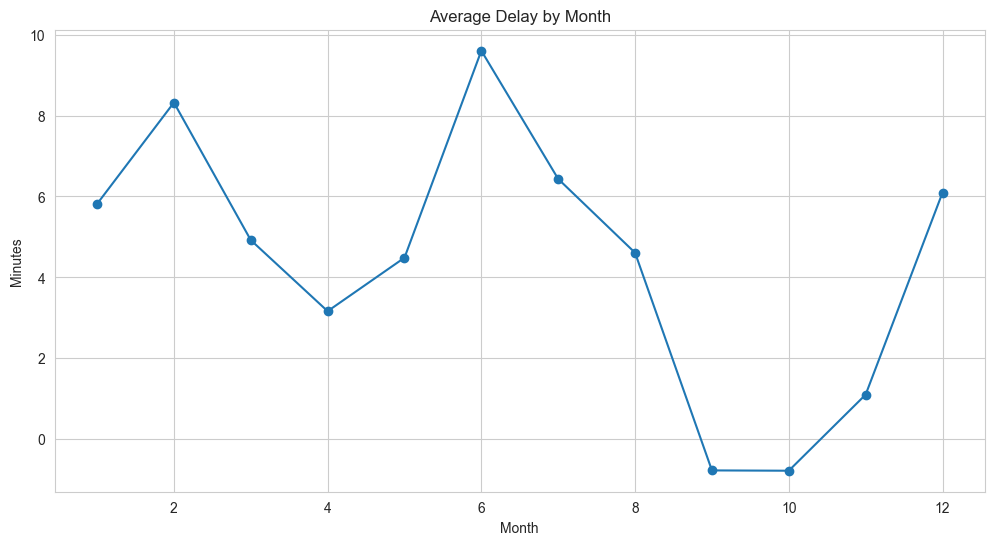

In [24]:
monthly_delays.plot(marker="o")

plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Minutes")
plt.show()

Certain months experience noticeably higher delays.

These peaks likely correspond to weather disruptions and increased travel demand.

13. Correlation Analysis

Does late aircraft arrival drive future delays?

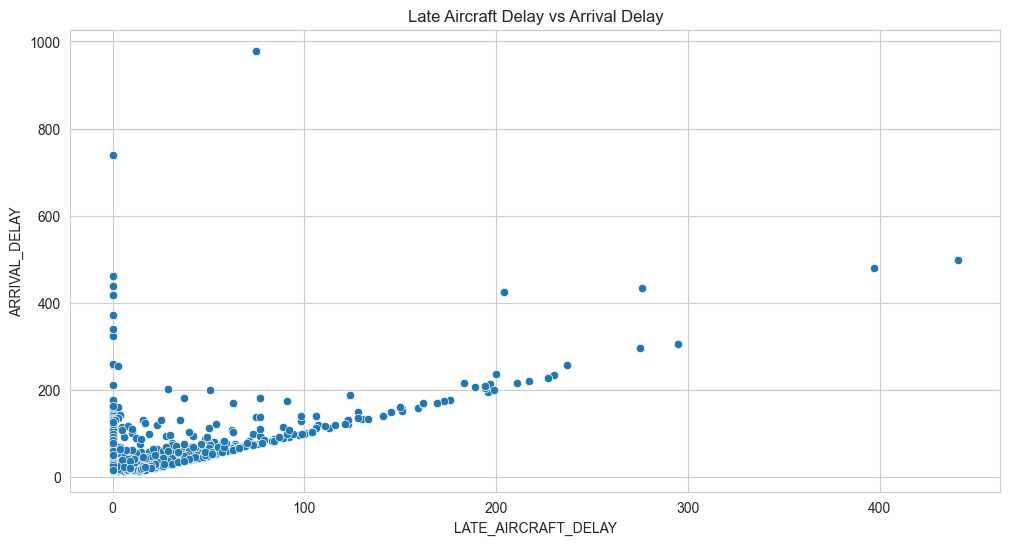

In [25]:
sns.scatterplot(
    data=df.sample(5000),
    x="LATE_AIRCRAFT_DELAY",
    y="ARRIVAL_DELAY"
)

plt.title("Late Aircraft Delay vs Arrival Delay")
plt.show()

In [28]:
df[
    [
        "ARRIVAL_DELAY",
        "LATE_AIRCRAFT_DELAY",
        "AIRLINE_DELAY",
        "AIR_SYSTEM_DELAY",
        "WEATHER_DELAY"
    ]
].corr()

,ARRIVAL_DELAY,LATE_AIRCRAFT_DELAY,AIRLINE_DELAY,AIR_SYSTEM_DELAY,WEATHER_DELAY
ARRIVAL_DELAY,1.000000,0.522013,0.609351,0.247187,0.264799
LATE_AIRCRAFT_DELAY,0.522013,1.000000,-0.106010,-0.145789,-0.021747
AIRLINE_DELAY,0.609351,-0.106010,1.000000,-0.120141,-0.050865
AIR_SYSTEM_DELAY,0.247187,-0.145789,-0.120141,1.000000,-0.000728
WEATHER_DELAY,0.264799,-0.021747,-0.050865,-0.000728,1.000000


Flights delayed by incoming aircraft are strongly associated with longer arrival delays.

This suggests delay propagation is a major contributor to passenger waiting time.

14. Testing The Hypothesis

Original Hypothesis

Operational factors contribute more delay minutes than weather-related events.

Calculate Operational Delay

In [32]:
operational_delay = (
    df["AIRLINE_DELAY"].sum()
    + df["AIR_SYSTEM_DELAY"].sum()
    + df["LATE_AIRCRAFT_DELAY"].sum()
)

weather_delay = df["WEATHER_DELAY"].sum()

print("Operational Delay Minutes:", operational_delay)
print("Weather Delay Minutes:", weather_delay)

Operational Delay Minutes: 59470649.0
Weather Delay Minutes: 3100233.0


Operational delays exceed weather delays by a substantial margin.

The hypothesis is supported.

15. Conclusion

## Findings

1. Delays impact significantly more passengers than cancellations.

2. Most delay minutes originate from operational issues rather than weather.

3. Late-arriving aircraft is one of the largest contributors to passenger waiting time.

4. Major hub airports create cascading delays throughout the national network.

5. Delay severity increases during high-demand travel periods.

## Answer To The Business Question

What causes Americans to spend millions of hours waiting in airports?

The primary causes are not extreme weather events but operational inefficiencies, including late-arriving aircraft, airline scheduling challenges, and airport congestion.

## Recommendations

- Improve aircraft turnaround efficiency.
- Increase schedule resilience during peak periods.
- Reduce congestion at major hub airports.
- Improve airline operational planning and recovery processes.